In [1]:
import pandas as pd
import numpy as np
import joblib
import json
import shap
import matplotlib.pyplot as plt

X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

final_model = joblib.load('../models/lgbm_tuned_clean.pkl')

with open('../models/lgbm_tuned_clean_threshold.json') as f:
    final_threshold = json.load(f)['threshold']

print(f'X_test shape: {X_test.shape}')
print(f'y_test death rate: {y_test.mean():.3f}')
print(f'Final threshold: {final_threshold}')

X_test shape: (18343, 379)
y_test death rate: 0.086
Final threshold: 0.7273530450209328


In [2]:
y_proba = final_model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= final_threshold).astype(int)

print(f'Predicted death rate: {y_pred.mean():.3f}')
print(f'Mean predicted probability: {y_proba.mean():.3f}')
print(f'Min probability: {y_proba.min():.3f}')
print(f'Max probability: {y_proba.max():.3f}')

Predicted death rate: 0.093
Mean predicted probability: 0.245
Min probability: 0.002
Max probability: 0.999


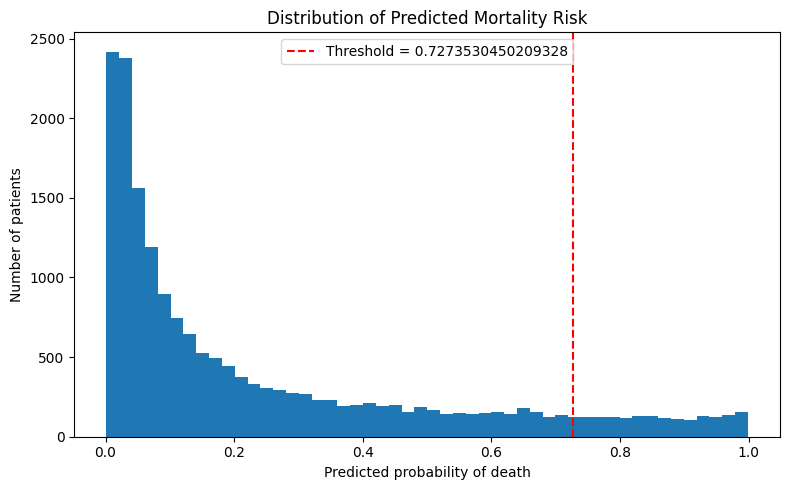

In [3]:
plt.figure(figsize=(8, 5))
plt.hist(y_proba, bins=50)
plt.axvline(final_threshold, color='red', linestyle='--', label=f'Threshold = {final_threshold}')
plt.xlabel('Predicted probability of death')
plt.ylabel('Number of patients')
plt.title('Distribution of Predicted Mortality Risk')
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
X_shap = X_test.copy()

print(f'X_shap shape: {X_shap.shape}')

X_shap shape: (18343, 379)


In [5]:
explainer = shap.TreeExplainer(final_model)

shap_values = explainer.shap_values(X_shap)

print('SHAP values calculated.')

SHAP values calculated.


/opt/anaconda3/lib/python3.13/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [6]:
type(shap_values)

numpy.ndarray

In [7]:
shap_values.shape

(18343, 379)

In [8]:
shap_importance = pd.DataFrame({
    'feature': X_shap.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

shap_importance.head(20)

,feature,mean_abs_shap
0,age,0.429324
318,ventilated_apache,0.277751
8,apache_3j_diagnosis,0.232076
85,d1_bun_max,0.138767
46,d1_spo2_min,0.137722
14,gcs_motor_apache,0.130756
15,gcs_verbal_apache,0.123716
36,d1_heartrate_min,0.119815
35,d1_heartrate_max,0.119779
43,d1_resprate_max,0.118402


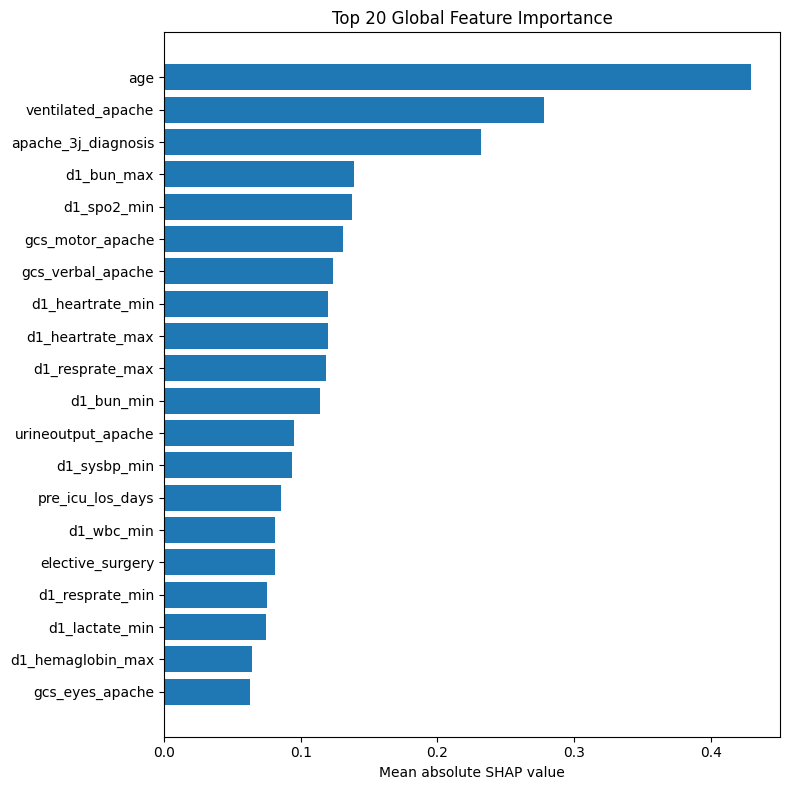

In [9]:
plt.figure(figsize=(8, 8))
top_features = shap_importance.head(20).sort_values('mean_abs_shap')

plt.barh(top_features['feature'], top_features['mean_abs_shap'])
plt.xlabel('Mean absolute SHAP value')
plt.title('Top 20 Global Feature Importance')
plt.tight_layout()
plt.show()

### Note on ID/location variables

Earlier exploratory SHAP work showed that `icu_id` could behave like a strong model signal even though it represents unit/location information rather than direct patient physiology. In the final preprocessing schema, ID and location-like columns such as `encounter_id`, `patient_id`, `hospital_id`, and `icu_id` are removed before model training.

Therefore, the refreshed SHAP analysis focuses on patient-level clinical variables, coded diagnosis/severity categories, laboratory values, vital signs, and treatment indicators. The earlier `icu_id` finding is still useful methodologically because it motivated a cleaner final preprocessing design.

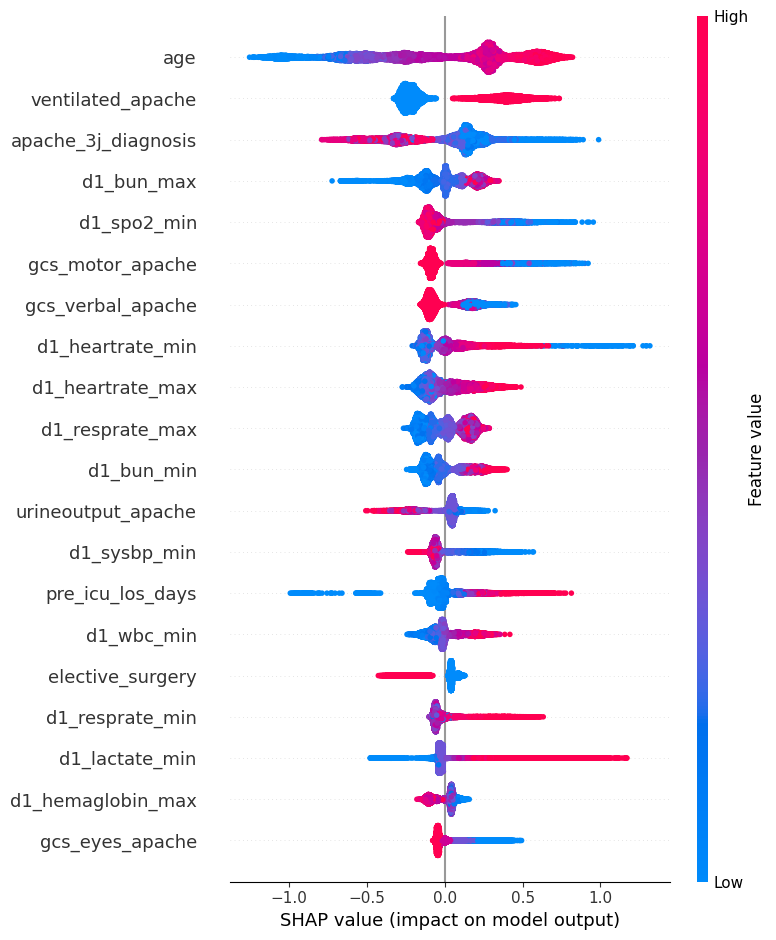

In [10]:
shap.summary_plot(
    shap_values,
    X_shap,
    max_display=20,
    show=True
)

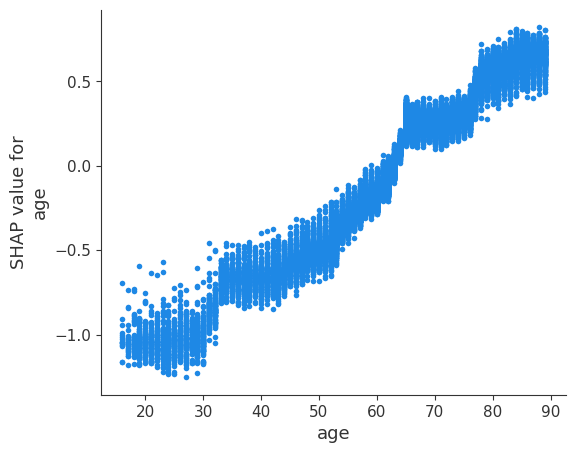

In [11]:
shap.dependence_plot(
    'age',
    shap_values,
    X_shap,
    interaction_index=None
)

In [12]:
age_shap_summary = pd.DataFrame({
    'age': X_shap['age'],
    'age_shap': shap_values[:, X_shap.columns.get_loc('age')]
})

age_shap_summary['age_group'] = pd.cut(
    age_shap_summary['age'],
    bins=[0, 40, 50, 60, 70, 80, 120],
    labels=['<=40', '41-50', '51-60', '61-70', '71-80', '80+']
)

age_shap_grouped = (
    age_shap_summary
    .groupby('age_group', observed=False)
    .agg(
        n_patients=('age', 'count'),
        mean_age=('age', 'mean'),
        mean_shap=('age_shap', 'mean'),
        median_shap=('age_shap', 'median')
    )
    .reset_index()
)

age_shap_grouped

,age_group,n_patients,mean_age,mean_shap,median_shap
0,<=40,2090,29.793780,-0.865013,-0.888065
1,41-50,1796,46.021715,-0.569291,-0.569077
2,51-60,3373,55.817670,-0.312499,-0.295353
3,61-70,4799,65.489269,0.174878,0.240393
4,71-80,3783,75.346815,0.379867,0.339017
5,80+,2502,84.476019,0.617652,0.622498


### Age SHAP Interpretation

Age shows a monotonic relationship with predicted mortality risk. Younger patients have negative SHAP contributions, while older age groups have positive contributions. This indicates that the final model uses increasing age as a risk-increasing factor for ICU mortality.

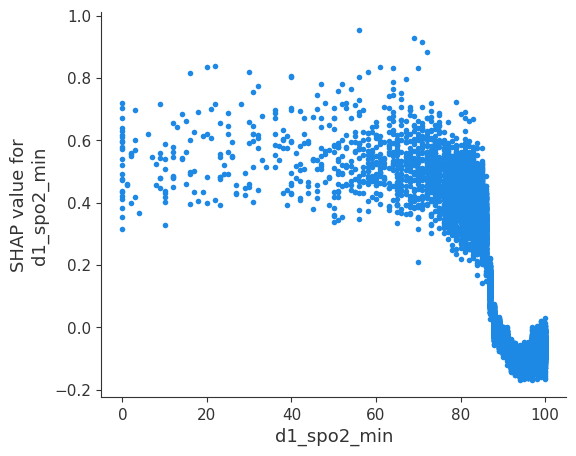

In [13]:
shap.dependence_plot(
    'd1_spo2_min',
    shap_values,
    X_shap,
    interaction_index=None
)

In [14]:
spo2_shap_summary = pd.DataFrame({
    'd1_spo2_min': X_shap['d1_spo2_min'],
    'spo2_shap': shap_values[:, X_shap.columns.get_loc('d1_spo2_min')]
})

spo2_shap_summary['spo2_group'] = pd.cut(
    spo2_shap_summary['d1_spo2_min'],
    bins=[0, 85, 90, 95, 100],
    labels=['<85', '85-90', '90-95', '95-100']
)

spo2_shap_grouped = (
    spo2_shap_summary
    .groupby('spo2_group', observed=False)
    .agg(
        n_patients=('d1_spo2_min', 'count'),
        mean_spo2=('d1_spo2_min', 'mean'),
        mean_shap=('spo2_shap', 'mean'),
        median_shap=('spo2_shap', 'median')
    )
    .reset_index()
)

spo2_shap_grouped

,spo2_group,n_patients,mean_spo2,mean_shap,median_shap
0,<85,2414,73.712510,0.448218,0.437799
1,85-90,3590,88.634540,0.029303,-0.016858
2,90-95,8363,93.039699,-0.096139,-0.099297
3,95-100,3953,97.329370,-0.092892,-0.097114


### Minimum SpO2 SHAP Interpretation

The SHAP dependence plot and grouped summary show that lower minimum SpO2 values increase predicted mortality risk. Patients with `d1_spo2_min` below 85 have strongly positive SHAP contributions, while values above 90 generally have negative contributions. This indicates that the model uses low oxygen saturation as an important risk-increasing signal.

In [15]:
vent_shap_summary = pd.DataFrame({
    'ventilated_apache': X_shap['ventilated_apache'],
    'vent_shap': shap_values[:, X_shap.columns.get_loc('ventilated_apache')]
})

vent_shap_grouped = (
    vent_shap_summary
    .groupby('ventilated_apache')
    .agg(
        n_patients=('ventilated_apache', 'count'),
        mean_shap=('vent_shap', 'mean'),
        median_shap=('vent_shap', 'median')
    )
    .reset_index()
)

vent_shap_grouped

,ventilated_apache,n_patients,mean_shap,median_shap
0,0.0,12416,-0.223409,-0.226681
1,1.0,5927,0.391589,0.395896


/var/folders/8q/6ppn3sn52s37836ffh2298v40000gn/T/ipykernel_64336/1300082300.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


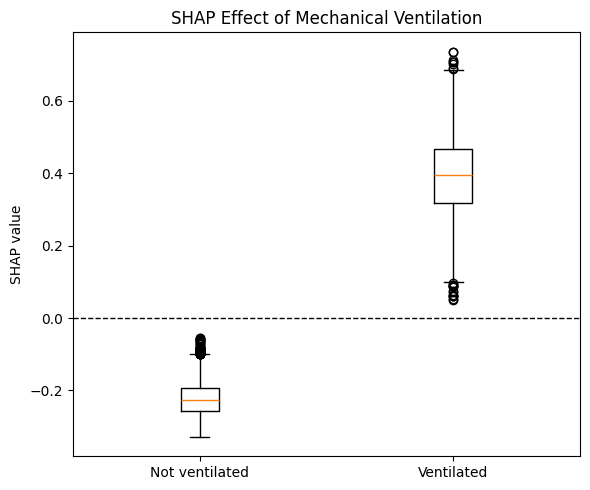

In [16]:
plt.figure(figsize=(6, 5))
plt.boxplot(
    [
        vent_shap_summary.loc[vent_shap_summary['ventilated_apache'] == 0, 'vent_shap'],
        vent_shap_summary.loc[vent_shap_summary['ventilated_apache'] == 1, 'vent_shap']
    ],
    labels=['Not ventilated', 'Ventilated']
)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.ylabel('SHAP value')
plt.title('SHAP Effect of Mechanical Ventilation')
plt.tight_layout()
plt.show()

### Mechanical Ventilation SHAP Interpretation

`ventilated_apache` shows a clear separation in SHAP contributions. Patients who were not ventilated had negative SHAP values, indicating reduced predicted mortality risk. Ventilated patients had strongly positive SHAP values, suggesting that the model uses mechanical ventilation as an important risk-increasing signal. This is clinically plausible because ventilation is often associated with severe respiratory failure or critical illness.

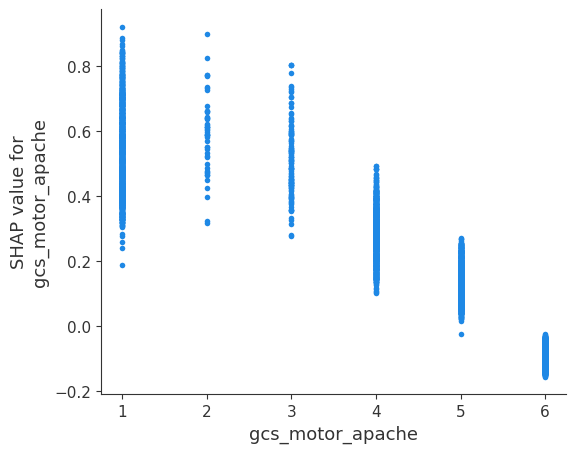

In [17]:
shap.dependence_plot(
    'gcs_motor_apache',
    shap_values,
    X_shap,
    interaction_index=None
)

In [18]:
gcs_motor_shap_summary = pd.DataFrame({
    'gcs_motor_apache': X_shap['gcs_motor_apache'],
    'gcs_motor_shap': shap_values[:, X_shap.columns.get_loc('gcs_motor_apache')]
})

gcs_motor_shap_grouped = (
    gcs_motor_shap_summary
    .groupby('gcs_motor_apache')
    .agg(
        n_patients=('gcs_motor_apache', 'count'),
        mean_shap=('gcs_motor_shap', 'mean'),
        median_shap=('gcs_motor_shap', 'median')
    )
    .reset_index()
    .sort_values('gcs_motor_apache')
)

gcs_motor_shap_grouped

,gcs_motor_apache,n_patients,mean_shap,median_shap
0,1.0,1088,0.535474,0.527085
1,2.0,48,0.590657,0.593923
2,3.0,117,0.516147,0.507745
3,4.0,913,0.282129,0.282081
4,5.0,1563,0.132960,0.131871
5,6.0,14614,-0.086333,-0.086333


### GCS Motor SHAP Interpretation

`gcs_motor_apache` shows an inverse relationship with predicted mortality risk. Lower motor scores have positive SHAP contributions, indicating increased mortality risk, while the highest motor score has a negative contribution. This suggests that the model uses impaired motor response as an important risk-increasing signal.

In [19]:
prediction_df = pd.DataFrame({
    'y_true': y_test.values,
    'y_proba': y_proba,
    'y_pred': y_pred
})

prediction_df['prediction_type'] = np.select(
    [
        (prediction_df['y_true'] == 1) & (prediction_df['y_pred'] == 1),
        (prediction_df['y_true'] == 1) & (prediction_df['y_pred'] == 0),
        (prediction_df['y_true'] == 0) & (prediction_df['y_pred'] == 1),
        (prediction_df['y_true'] == 0) & (prediction_df['y_pred'] == 0),
    ],
    ['TP', 'FN', 'FP', 'TN'],
    default='Unknown'
)

prediction_df['prediction_type'].value_counts()

prediction_type
TN    15952
TP      903
FP      808
FN      680
Name: count, dtype: int64

In [20]:
tp_idx = (
    prediction_df[prediction_df['prediction_type'] == 'TP']
    .sort_values('y_proba', ascending=False)
    .index[0]
)

tp_idx, prediction_df.loc[tp_idx]

(np.int64(7773),
 y_true                    1
 y_proba            0.998875
 y_pred                    1
 prediction_type          TP
 Name: 7773, dtype: object)

In [21]:
def explain_patient(index, X, shap_values, prediction_df, top_n=10):
    patient_shap = pd.DataFrame({
        'feature': X.columns,
        'value': X.iloc[index].values,
        'shap_value': shap_values[index]
    })

    patient_shap['abs_shap'] = patient_shap['shap_value'].abs()

    print('Prediction info:')
    display(prediction_df.loc[index])

    print('\nTop risk-increasing features:')
    display(
        patient_shap
        .sort_values('shap_value', ascending=False)
        .head(top_n)
        [['feature', 'value', 'shap_value']]
    )

    print('\nTop risk-decreasing features:')
    display(
        patient_shap
        .sort_values('shap_value', ascending=True)
        .head(top_n)
        [['feature', 'value', 'shap_value']]
    )

    return patient_shap.sort_values('abs_shap', ascending=False)

tp_explanation = explain_patient(
    tp_idx,
    X_shap,
    shap_values,
    prediction_df,
    top_n=10
)

Prediction info:


y_true                    1
y_proba            0.998875
y_pred                    1
prediction_type          TP
Name: 7773, dtype: object


Top risk-increasing features:


,feature,value,shap_value
36,d1_heartrate_min,0.00,1.138222
102,d1_lactate_min,8.70,0.782119
46,d1_spo2_min,70.00,0.561348
8,apache_3j_diagnosis,102.01,0.440532
14,gcs_motor_apache,1.00,0.338107
144,d1_arterial_ph_min,6.89,0.336470
318,ventilated_apache,1.00,0.325105
50,d1_sysbp_min,60.00,0.314144
143,d1_arterial_ph_max,7.08,0.297957
101,d1_lactate_max,17.00,0.260873



Top risk-decreasing features:


,feature,value,shap_value
327,ethnicity_African American,1.00,-0.077615
321,diabetes_mellitus,1.00,-0.064262
132,h1_lactate_min,8.70,-0.063807
61,h1_heartrate_max,134.00,-0.048479
154,h1_arterial_po2_min,62.00,-0.039856
329,ethnicity_Caucasian,0.00,-0.032690
54,d1_temp_min,36.27,-0.030779
107,d1_sodium_max,143.00,-0.026805
119,h1_creatinine_max,4.24,-0.023785
104,d1_platelets_min,147.00,-0.022632


In [22]:
(X_test['d1_heartrate_min'] == 0).sum()

np.int64(129)

In [23]:
hr_zero_mask = X_test['d1_heartrate_min'] == 0

print(f'Patients with d1_heartrate_min = 0: {hr_zero_mask.sum()}')
print(f'Death rate when d1_heartrate_min = 0: {y_test[hr_zero_mask].mean():.3f}')
print(f'Death rate when d1_heartrate_min > 0: {y_test[~hr_zero_mask].mean():.3f}')

Patients with d1_heartrate_min = 0: 129
Death rate when d1_heartrate_min = 0: 0.651
Death rate when d1_heartrate_min > 0: 0.082


In [24]:
hr_min = X_shap['d1_heartrate_min']

print(f'Sıfır olan hasta sayısı: {(hr_min == 0).sum()}')
print(f'Toplam hasta: {len(hr_min)}')
print(f'Oran: {(hr_min == 0).mean():.3f}')
print()
print(hr_min.describe())


Sıfır olan hasta sayısı: 129
Toplam hasta: 18343
Oran: 0.007

count    18343.000000
mean        70.180287
std         17.260900
min          0.000000
25%         60.000000
50%         69.000000
75%         80.000000
max        155.000000
Name: d1_heartrate_min, dtype: float64


### Note on `d1_heartrate_min = 0`

In the local true positive explanation, `d1_heartrate_min = 0` had the largest positive SHAP contribution. This value is physiologically extreme and may represent a true critical event such as cardiac arrest or peri-arrest, but it may also reflect a recording artifact or data quality issue.

In the test set, 129 patients (0.7%) had `d1_heartrate_min = 0`. Their observed mortality rate was 65.1%, compared with 8.2% among patients with `d1_heartrate_min > 0`. Because this rare value is strongly associated with mortality, it was retained for the current analysis but should be interpreted with caution. A future sensitivity analysis should evaluate model behavior after treating physiologically implausible zero vital signs as missing or outlier values.

In [25]:
fn_idx = (
    prediction_df[prediction_df['prediction_type'] == 'FN']
    .sort_values('y_proba', ascending=True)
    .index[0]
)

fn_idx, prediction_df.loc[fn_idx]

(np.int64(7920),
 y_true                    1
 y_proba            0.019213
 y_pred                    0
 prediction_type          FN
 Name: 7920, dtype: object)

In [26]:
fn_explanation = explain_patient(
    fn_idx,
    X_shap,
    shap_values,
    prediction_df,
    top_n=10
)

Prediction info:


y_true                    1
y_proba            0.019213
y_pred                    0
prediction_type          FN
Name: 7920, dtype: object


Top risk-increasing features:


,feature,value,shap_value
364,apache_3j_bodysystem_Neurological,1.0,0.162779
88,d1_calcium_min,9.4,0.115244
357,icu_type_Neuro ICU,1.0,0.109104
92,d1_glucose_min,173.0,0.103609
106,d1_potassium_min,5.1,0.073119
36,d1_heartrate_min,81.0,0.065721
91,d1_glucose_max,210.0,0.058750
43,d1_resprate_max,27.0,0.056286
373,apache_2_bodysystem_Neurologic,1.0,0.047136
70,h1_resprate_min,23.0,0.045792



Top risk-decreasing features:


,feature,value,shap_value
0,age,28.000000,-1.074370
318,ventilated_apache,0.000000,-0.254844
85,d1_bun_max,8.000000,-0.231894
27,urineoutput_apache,1790.121600,-0.226839
86,d1_bun_min,8.000000,-0.119203
3,pre_icu_los_days,0.000694,-0.110235
46,d1_spo2_min,94.000000,-0.099439
345,icu_admit_source_Operating Room / Recovery,1.000000,-0.096356
15,gcs_verbal_apache,5.000000,-0.095872
14,gcs_motor_apache,6.000000,-0.087830


In [27]:
(X_test['h1_resprate_min'] == 0).sum()

np.int64(147)

In [28]:
rr_zero_mask = X_test['h1_resprate_min'] == 0

print(f'Patients with h1_resprate_min = 0: {rr_zero_mask.sum()}')
print(f'Death rate when h1_resprate_min = 0: {y_test[rr_zero_mask].mean():.3f}')
print(f'Death rate when h1_resprate_min > 0: {y_test[~rr_zero_mask].mean():.3f}')

Patients with h1_resprate_min = 0: 147
Death rate when h1_resprate_min = 0: 0.129
Death rate when h1_resprate_min > 0: 0.086


### Error Analysis Note — False Negative Case

The selected false negative case corresponds to a patient who died but was assigned a low predicted mortality probability by the model. The local SHAP explanation shows strong risk-decreasing contributions from younger age, absence of mechanical ventilation, lower BUN values, and urine output. Some risk-increasing signals are present, including neurological body-system information and selected lab values, but they do not outweigh the risk-decreasing evidence.

This case suggests that the model may miss mortality cases when classical high-risk indicators are weak, absent, or outweighed by lower-risk features.

In [29]:
fp_idx = (
    prediction_df[prediction_df['prediction_type'] == 'FP']
    .sort_values('y_proba', ascending=False)
    .index[0]
)

fp_idx, prediction_df.loc[fp_idx]

(np.int64(1963),
 y_true                    0
 y_proba            0.997142
 y_pred                    1
 prediction_type          FP
 Name: 1963, dtype: object)

In [30]:
fp_explanation = explain_patient(
    fp_idx,
    X_shap,
    shap_values,
    prediction_df,
    top_n=10
)

Prediction info:


y_true                    0
y_proba            0.997142
y_pred                    1
prediction_type          FP
Name: 1963, dtype: object


Top risk-increasing features:


,feature,value,shap_value
36,d1_heartrate_min,0.00000,1.139514
102,d1_lactate_min,11.90000,1.014255
46,d1_spo2_min,32.00000,0.616857
50,d1_sysbp_min,41.00000,0.403514
8,apache_3j_diagnosis,101.01000,0.395945
143,d1_arterial_ph_max,7.05428,0.341749
144,d1_arterial_ph_min,6.90000,0.337043
318,ventilated_apache,1.00000,0.322705
40,d1_mbp_min,25.00000,0.252237
93,d1_hco3_max,12.00000,0.246185



Top risk-decreasing features:


,feature,value,shap_value
0,age,47.000000,-0.461397
121,h1_glucose_max,61.000000,-0.099722
72,h1_spo2_min,64.000000,-0.090780
321,diabetes_mellitus,1.000000,-0.058761
3,pre_icu_los_days,0.033333,-0.052178
39,d1_mbp_max,123.000000,-0.042161
31,d1_diasbp_max,115.000000,-0.041443
64,h1_mbp_invasive_min,64.000000,-0.041236
54,d1_temp_min,36.400000,-0.041143
92,d1_glucose_min,61.000000,-0.039212


### Local Explanation — False Positive Case

This false positive case corresponds to a patient who survived (`y_true = 0`) but received a very high predicted mortality probability. The strongest risk-increasing features include `d1_heartrate_min = 0`, high lactate, low SpO2, low systolic/mean blood pressure, low arterial pH, diagnosis category information, and mechanical ventilation.

Although the patient survived, the model's high-risk prediction is clinically understandable because several early physiological features suggested severe instability. This case reinforces the need to interpret zero-valued vital signs and extreme measurements carefully.

In [31]:
tn_idx = (
    prediction_df[prediction_df['prediction_type'] == 'TN']
    .sort_values('y_proba', ascending=True)
    .index[0]
)

tn_idx, prediction_df.loc[tn_idx]

(np.int64(14835),
 y_true                   0
 y_proba            0.00151
 y_pred                   0
 prediction_type         TN
 Name: 14835, dtype: object)

In [32]:
tn_explanation = explain_patient(
    tn_idx,
    X_shap,
    shap_values,
    prediction_df,
    top_n=10
)

Prediction info:


y_true                   0
y_proba            0.00151
y_pred                   0
prediction_type         TN
Name: 14835, dtype: object


Top risk-increasing features:


,feature,value,shap_value
312,elective_surgery,0.000000,0.032846
80,h1_temp_min,36.600000,0.024616
1,bmi,23.596884,0.023549
345,icu_admit_source_Operating Room / Recovery,0.000000,0.020178
313,gender,1.000000,0.018640
9,bilirubin_apache,0.620000,0.018013
40,d1_mbp_min,59.000000,0.017088
359,apache_3j_bodysystem_Cardiovascular,0.000000,0.014071
369,apache_2_bodysystem_Cardiovascular,0.000000,0.014047
121,h1_glucose_max,140.000000,0.011711



Top risk-decreasing features:


,feature,value,shap_value
0,age,28.0000,-0.989819
362,apache_3j_bodysystem_Metabolic,1.0000,-0.311151
8,apache_3j_diagnosis,703.0300,-0.283484
318,ventilated_apache,0.0000,-0.210506
43,d1_resprate_max,19.0000,-0.191008
27,urineoutput_apache,2128.9824,-0.185391
96,d1_hemaglobin_min,14.7000,-0.128100
86,d1_bun_min,12.0000,-0.122583
85,d1_bun_max,12.0000,-0.120580
84,d1_bilirubin_min,0.3000,-0.113101


### Local Explanation — True Negative Case

This true negative case corresponds to a patient who survived and received a very low predicted mortality probability. The strongest risk-decreasing signals include younger age, absence of mechanical ventilation, metabolic/diagnosis category information, lower-risk respiratory patterns, higher urine output, and less severe laboratory values.

Unlike the earlier prototype, `icu_id` is not part of the final feature set, so this local explanation is driven by patient-level clinical and coded severity information rather than unit/location identifiers.

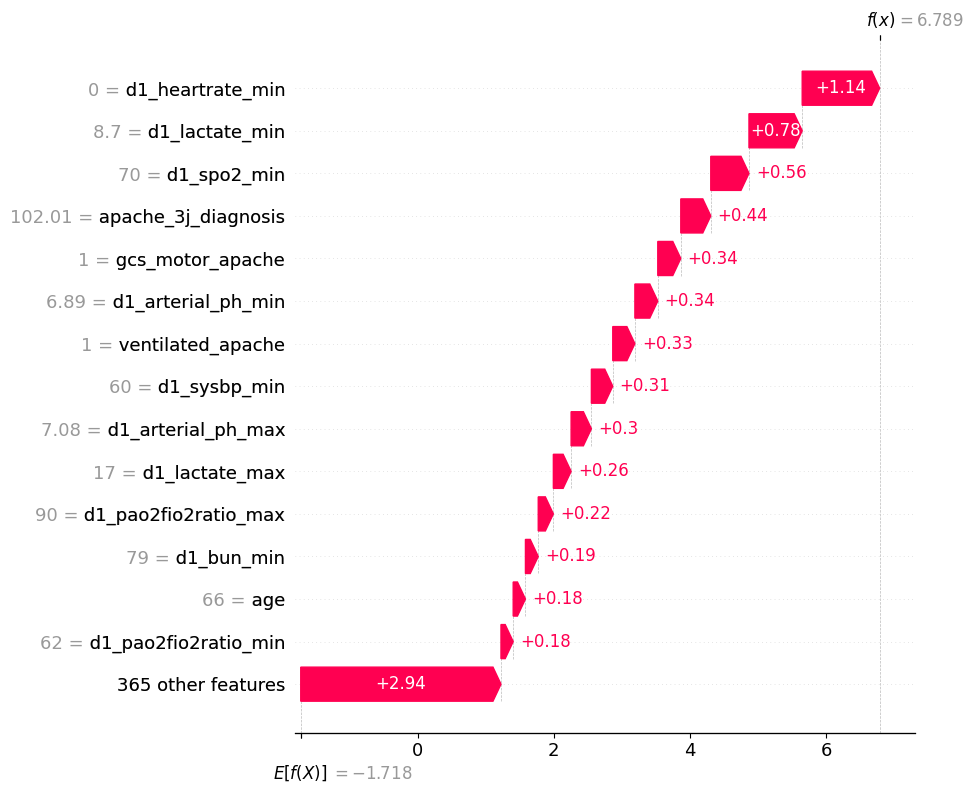

In [33]:
expected_value = explainer.expected_value

if isinstance(expected_value, list):
    expected_value = expected_value[1]

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[tp_idx],
        base_values=expected_value,
        data=X_shap.iloc[tp_idx],
        feature_names=X_shap.columns
    ),
    max_display=15
)

In [34]:
def plot_patient_waterfall(index, title=None, max_display=15):
    expected_value = explainer.expected_value

    if isinstance(expected_value, list):
        expected_value = expected_value[1]

    if title is not None:
        print(title)

    display(prediction_df.loc[index])

    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values[index],
            base_values=expected_value,
            data=X_shap.iloc[index],
            feature_names=X_shap.columns
        ),
        max_display=max_display
    )

True Positive Patient


y_true                    1
y_proba            0.998875
y_pred                    1
prediction_type          TP
Name: 7773, dtype: object

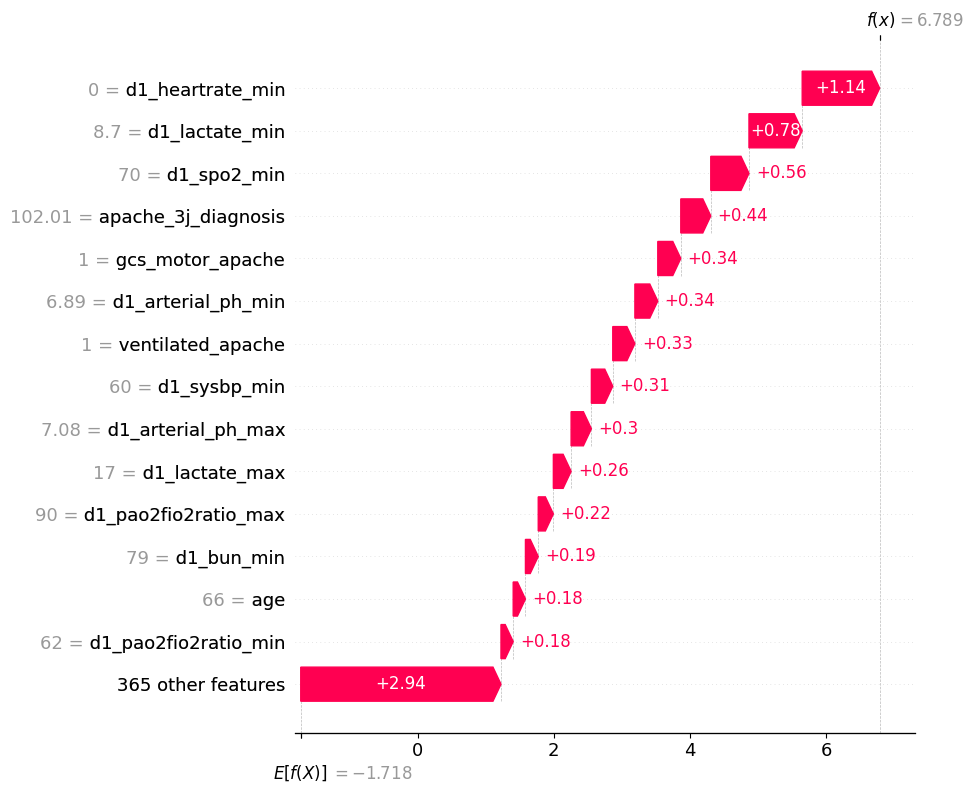

False Negative Patient


y_true                    1
y_proba            0.019213
y_pred                    0
prediction_type          FN
Name: 7920, dtype: object

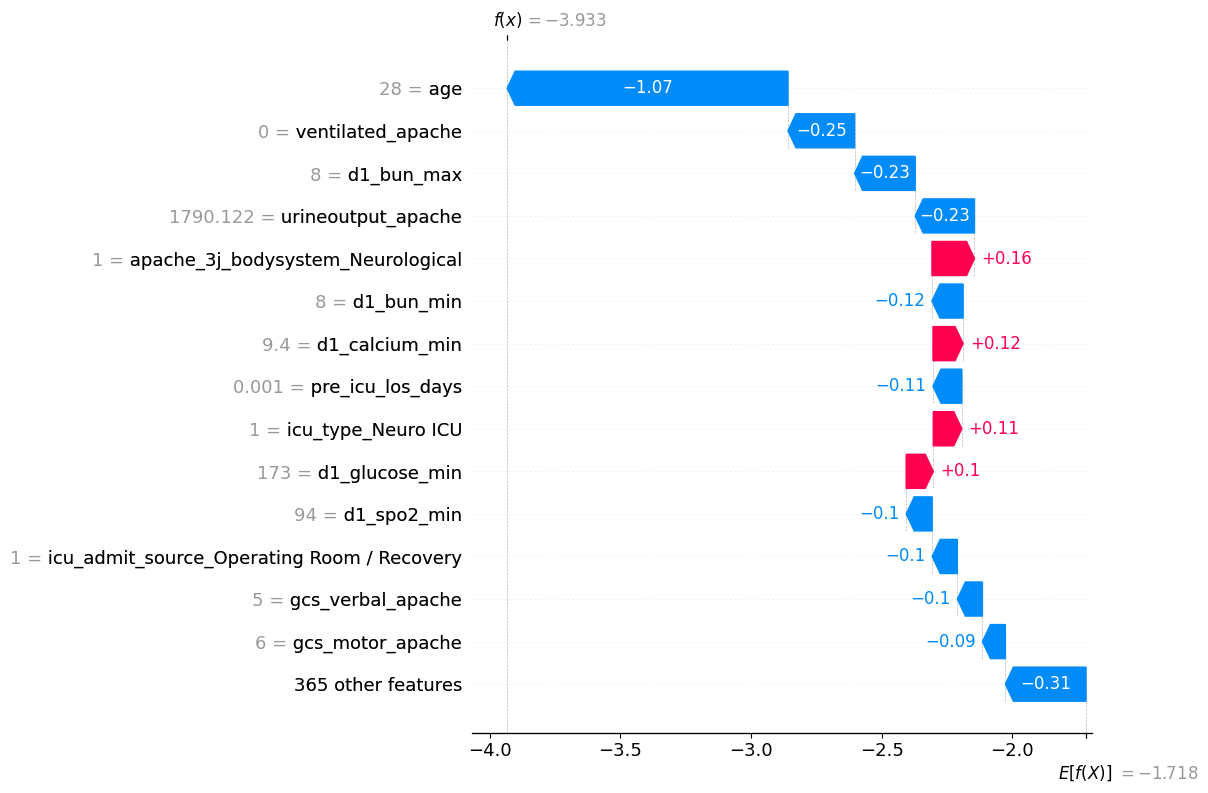

False Positive Patient


y_true                    0
y_proba            0.997142
y_pred                    1
prediction_type          FP
Name: 1963, dtype: object

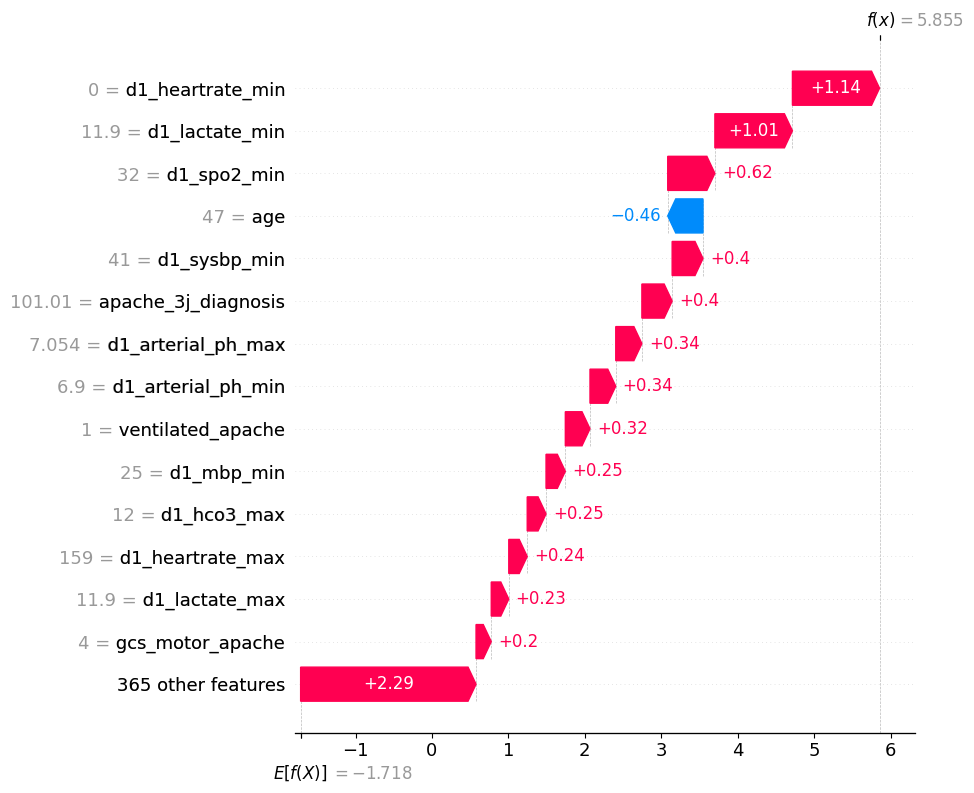

True Negative Patient


y_true                   0
y_proba            0.00151
y_pred                   0
prediction_type         TN
Name: 14835, dtype: object

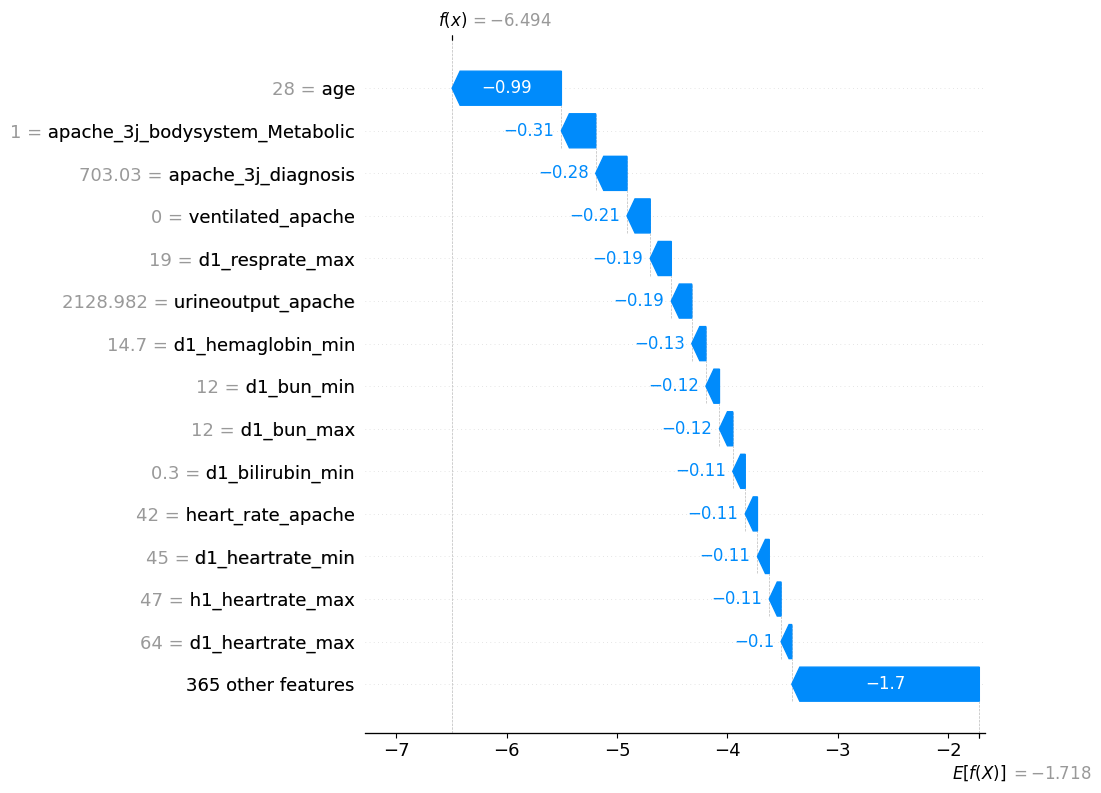

In [35]:
plot_patient_waterfall(tp_idx, title='True Positive Patient')
plot_patient_waterfall(fn_idx, title='False Negative Patient')
plot_patient_waterfall(fp_idx, title='False Positive Patient')
plot_patient_waterfall(tn_idx, title='True Negative Patient')

In [36]:
shap_df = pd.DataFrame(shap_values, columns=X_shap.columns)
shap_df['prediction_type'] = prediction_df['prediction_type'].values

group_mean_shap = (
    shap_df
    .groupby('prediction_type')
    .mean()
)

group_mean_abs_shap = (
    shap_df
    .drop(columns='prediction_type')
    .abs()
    .assign(prediction_type=prediction_df['prediction_type'].values)
    .groupby('prediction_type')
    .mean()
)

In [37]:
def top_group_shap(group_name, n=10):
    mean_shap = group_mean_shap.loc[group_name].sort_values(ascending=False)
    mean_abs_shap = group_mean_abs_shap.loc[group_name].sort_values(ascending=False)

    print(f'=== {group_name} — Top Mean Positive SHAP ===')
    display(mean_shap.head(n).reset_index().rename(columns={'index': 'feature', group_name: 'mean_shap'}))

    print(f'=== {group_name} — Top Mean Absolute SHAP ===')
    display(mean_abs_shap.head(n).reset_index().rename(columns={'index': 'feature', group_name: 'mean_abs_shap'}))

In [38]:
for group in ['TP', 'FN', 'FP', 'TN']:
    top_group_shap(group, n=10)

=== TP — Top Mean Positive SHAP ===


,feature,mean_shap
0,ventilated_apache,0.309503
1,d1_lactate_min,0.259003
2,apache_3j_diagnosis,0.257061
3,gcs_motor_apache,0.255220
4,d1_spo2_min,0.198545
5,age,0.173228
6,d1_heartrate_min,0.145154
7,d1_sysbp_min,0.140866
8,gcs_verbal_apache,0.130203
9,gcs_eyes_apache,0.126437


=== TP — Top Mean Absolute SHAP ===


,feature,mean_abs_shap
0,ventilated_apache,0.371590
1,age,0.349098
2,gcs_motor_apache,0.302834
3,apache_3j_diagnosis,0.299992
4,d1_lactate_min,0.294918
5,d1_spo2_min,0.262635
6,d1_heartrate_min,0.205443
7,d1_sysbp_min,0.177292
8,gcs_verbal_apache,0.154166
9,gcs_eyes_apache,0.148218


=== FN — Top Mean Positive SHAP ===


...

,feature,mean_abs_shap
0,age,0.374728
1,ventilated_apache,0.358584
2,apache_3j_diagnosis,0.242267
3,gcs_motor_apache,0.241865
4,d1_spo2_min,0.218003
5,d1_lactate_min,0.172895
6,d1_sysbp_min,0.151767
7,d1_bun_max,0.150757
8,gcs_verbal_apache,0.148217
9,d1_heartrate_min,0.142572


=== TN — Top Mean Positive SHAP ===


,feature,mean_shap
0,d1_creatinine_min,0.006079
1,h1_heartrate_max,0.003070
2,d1_hematocrit_min,0.002997
3,d1_hematocrit_max,0.002512
4,h1_heartrate_min,0.002432
5,apache_3j_bodysystem_Sepsis,0.002153
6,d1_arterial_ph_max_missing,0.001901
7,h1_sysbp_noninvasive_min,0.001873
8,h1_spo2_min,0.001536
9,d1_inr_min,0.001486


=== TN — Top Mean Absolute SHAP ===


,feature,mean_abs_shap
0,age,0.437724
1,ventilated_apache,0.267116
2,apache_3j_diagnosis,0.228147
3,d1_bun_max,0.137263
4,d1_spo2_min,0.126043
5,d1_resprate_max,0.120420
6,gcs_verbal_apache,0.120284
7,d1_heartrate_max,0.118098
8,gcs_motor_apache,0.114407
9,d1_bun_min,0.114256


In [39]:
import os

os.makedirs('../reports/02_explainability', exist_ok=True)

shap_importance.to_csv(
    '../reports/02_explainability/tables/global_shap_importance.csv',
    index=False
)

prediction_df.to_csv(
    '../reports/02_explainability/tables/prediction_types.csv',
    index=False
)

tp_explanation.to_csv(
    '../reports/02_explainability/tables/local_explanation_tp.csv',
    index=False
)

fn_explanation.to_csv(
    '../reports/02_explainability/tables/local_explanation_fn.csv',
    index=False
)

fp_explanation.to_csv(
    '../reports/02_explainability/tables/local_explanation_fp.csv',
    index=False
)

tn_explanation.to_csv(
    '../reports/02_explainability/tables/local_explanation_tn.csv',
    index=False
)

group_mean_shap.to_csv(
    '../reports/02_explainability/tables/group_mean_shap.csv'
)

group_mean_abs_shap.to_csv(
    '../reports/02_explainability/tables/group_mean_abs_shap.csv'
)

print('Explainability outputs saved.')

Explainability outputs saved.


## Explainability Summary

This notebook analyzes the final LightGBM model using SHAP on the held-out test set. Global SHAP analysis shows that the model relies on clinically meaningful features such as age, mechanical ventilation, diagnosis category information, BUN, minimum SpO2, GCS motor/verbal scores, heart-rate features, respiratory rate, urine output, and other laboratory/vital-sign variables.

Feature-level analyses show clinically plausible patterns: older age, low oxygen saturation, mechanical ventilation, and impaired GCS motor response increase predicted mortality risk. Local explanations for TP, FN, FP, and TN cases show how the model behaves across correct predictions and error cases.

The earlier `icu_id` concern was addressed by removing ID/location columns in the final preprocessing schema. Remaining caution areas include zero-valued vital signs, coded diagnosis categories that should not be over-interpreted, and unusual time-related values such as `pre_icu_los_days`.

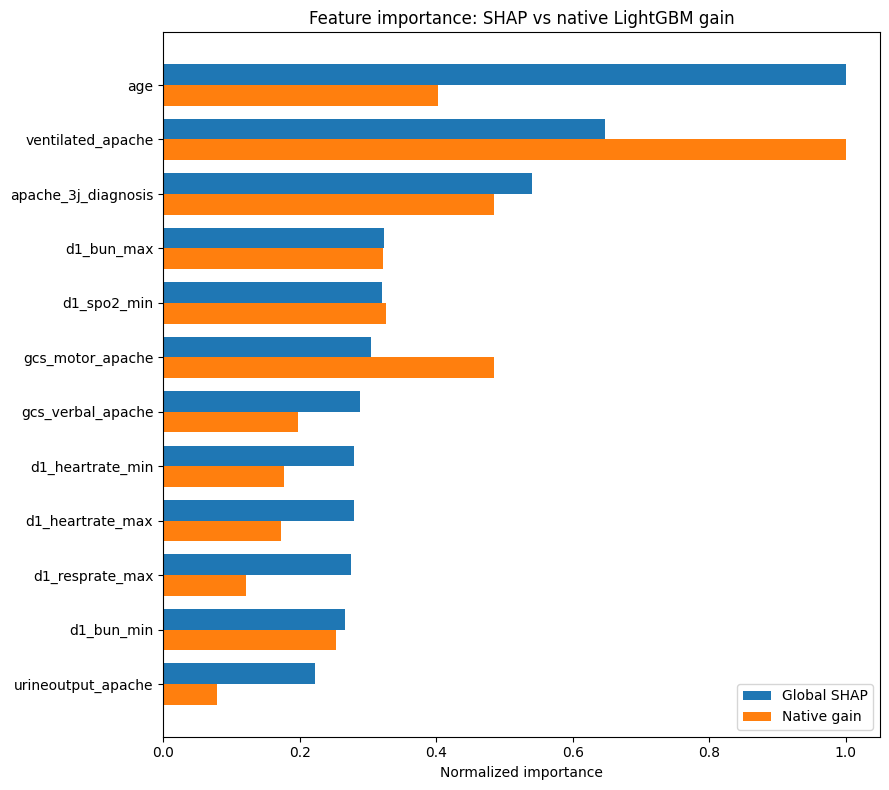

,feature,mean_abs_shap,gain_importance,rank_shap,rank_gain
0,age,0.429324,76620.768715,1.0,4.0
1,ventilated_apache,0.277751,190141.624290,2.0,1.0
2,apache_3j_diagnosis,0.232076,92089.209243,3.0,2.0
3,d1_bun_max,0.138767,61232.608698,4.0,8.0
4,d1_spo2_min,0.137722,62028.798883,5.0,7.0
5,gcs_motor_apache,0.130756,92059.495836,6.0,3.0
6,gcs_verbal_apache,0.123716,37701.907918,7.0,10.0
7,d1_heartrate_min,0.119815,33766.643725,8.0,11.0
8,d1_heartrate_max,0.119779,32947.936169,9.0,12.0
9,d1_resprate_max,0.118402,22965.066471,10.0,18.0


In [40]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

explainability_dir = Path('../reports/02_explainability')
modeling_dir = Path('../reports/01_modeling')

try:
    shap_importance
except NameError:
    shap_importance = pd.read_csv(explainability_dir / 'global_shap_importance.csv')

native_importance = pd.read_csv(modeling_dir / 'native_lgbm_feature_importance.csv')

comp = shap_importance.merge(
    native_importance[['feature', 'gain_importance']],
    on='feature',
    how='inner'
).copy()

comp['rank_shap'] = comp['mean_abs_shap'].rank(ascending=False, method='min')
comp['rank_gain'] = comp['gain_importance'].rank(ascending=False, method='min')

top = comp.sort_values('rank_shap').head(12).copy()
top['shap_norm'] = top['mean_abs_shap'] / comp['mean_abs_shap'].max()
top['gain_norm'] = top['gain_importance'] / comp['gain_importance'].max()
top = top.sort_values('rank_shap').iloc[::-1]

y = np.arange(len(top))
h = 0.38

plt.figure(figsize=(9, 8))
plt.barh(y + h/2, top['shap_norm'], height=h, label='Global SHAP')
plt.barh(y - h/2, top['gain_norm'], height=h, label='Native gain')
plt.yticks(y, top['feature'])
plt.xlabel('Normalized importance')
plt.title('Feature importance: SHAP vs native LightGBM gain')
plt.legend()
plt.tight_layout()
plt.show()

comp.sort_values('rank_shap').head(12)[
    ['feature', 'mean_abs_shap', 'gain_importance', 'rank_shap', 'rank_gain']
]

In [41]:
from pathlib import Path
import itertools
import re
import pandas as pd

explainability_dir = Path("../reports/02_explainability")
dependence_dir = explainability_dir / "top20_dependence_plots"
dependence_dir.mkdir(parents=True, exist_ok=True)

try:
    shap_importance
except NameError:
    shap_importance = pd.read_csv(
        explainability_dir / "global_shap_importance.csv"
    )

top20_features = shap_importance.head(20)["feature"].tolist()

top20_features_df = shap_importance.head(20).reset_index(drop=True)
top20_features_df["rank"] = top20_features_df.index + 1
top20_features_df = top20_features_df[["rank", "feature", "mean_abs_shap"]]

top20_features_df.to_csv(
    explainability_dir / "top20_shap_features.csv",
    index=False
)

top20_features_df

,rank,feature,mean_abs_shap
0,1,age,0.429324
1,2,ventilated_apache,0.277751
2,3,apache_3j_diagnosis,0.232076
3,4,d1_bun_max,0.138767
4,5,d1_spo2_min,0.137722
5,6,gcs_motor_apache,0.130756
6,7,gcs_verbal_apache,0.123716
7,8,d1_heartrate_min,0.119815
8,9,d1_heartrate_max,0.119779
9,10,d1_resprate_max,0.118402


In [42]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
from pathlib import Path

explainability_dir = Path("../reports/02_explainability")
dependence_dir = explainability_dir / "top20_dependence_plots"
dependence_dir.mkdir(parents=True, exist_ok=True)

try:
    X_shap
except NameError:
    X_test = pd.read_csv("../data/processed/X_test.csv")
    X_shap = X_test.copy()

try:
    final_model
except NameError:
    final_model = joblib.load("../models/lgbm_tuned_clean.pkl")

try:
    explainer
except NameError:
    explainer = shap.TreeExplainer(final_model)

try:
    shap_values
except NameError:
    shap_values = explainer.shap_values(X_shap)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

try:
    shap_importance
except NameError:
    shap_importance = pd.read_csv(
        explainability_dir / "global_shap_importance.csv"
    )

try:
    top20_features
except NameError:
    top20_features = shap_importance.head(20)["feature"].tolist()

print("X_shap shape:", X_shap.shape)
print("shap_values shape:", shap_values.shape)
print("Top 20 features:", top20_features)

X_shap shape: (18343, 379)
shap_values shape: (18343, 379)
Top 20 features: ['age', 'ventilated_apache', 'apache_3j_diagnosis', 'd1_bun_max', 'd1_spo2_min', 'gcs_motor_apache', 'gcs_verbal_apache', 'd1_heartrate_min', 'd1_heartrate_max', 'd1_resprate_max', 'd1_bun_min', 'urineoutput_apache', 'd1_sysbp_min', 'pre_icu_los_days', 'd1_wbc_min', 'elective_surgery', 'd1_resprate_min', 'd1_lactate_min', 'd1_hemaglobin_max', 'gcs_eyes_apache']


In [43]:
interaction_sample_size = min(300, len(X_shap))

X_interaction_sample = X_shap.sample(
    n=interaction_sample_size,
    random_state=42
)

interaction_values = explainer.shap_interaction_values(X_interaction_sample)

if isinstance(interaction_values, list):
    interaction_values = interaction_values[1]

print(f"Interaction sample shape: {X_interaction_sample.shape}")
print(f"Interaction values shape: {interaction_values.shape}")

Interaction sample shape: (300, 379)
Interaction values shape: (300, 379, 379)


In [44]:
top20_indices = [X_shap.columns.get_loc(feature) for feature in top20_features]

top20_interaction_values = interaction_values[:, top20_indices, :][:, :, top20_indices]

mean_abs_interaction_matrix = np.abs(top20_interaction_values).mean(axis=0)

# Diagonal main effect olduğu için pairwise interaction sıralamasında sıfırlıyoruz.
np.fill_diagonal(mean_abs_interaction_matrix, 0)

interaction_matrix_df = pd.DataFrame(
    mean_abs_interaction_matrix,
    index=top20_features,
    columns=top20_features
)

interaction_matrix_df.to_csv(
    explainability_dir / "top20_shap_interaction_matrix.csv"
)

interaction_matrix_df

,age,ventilated_apache,apache_3j_diagnosis,d1_bun_max,d1_spo2_min,gcs_motor_apache,gcs_verbal_apache,d1_heartrate_min,d1_heartrate_max,d1_resprate_max,d1_bun_min,urineoutput_apache,d1_sysbp_min,pre_icu_los_days,d1_wbc_min,elective_surgery,d1_resprate_min,d1_lactate_min,d1_hemaglobin_max,gcs_eyes_apache
age,0.000000,0.009733,0.004070,0.002580,0.003654,0.006319,0.002591,0.005411,0.012216,0.003813,0.003750,0.001272,0.004030,0.002917,0.003157,0.006453,0.002782,0.004384,0.002310,0.002428
ventilated_apache,0.009733,0.000000,0.023767,0.005324,0.004340,0.009202,0.008020,0.002684,0.004019,0.005948,0.011514,0.003799,0.006007,0.003539,0.000579,0.025626,0.002317,0.003831,0.000025,0.001155
apache_3j_diagnosis,0.004070,0.023767,0.000000,0.003426,0.004581,0.010234,0.004017,0.001707,0.001549,0.001885,0.002001,0.001418,0.002771,0.002691,0.006506,0.008261,0.001831,0.003480,0.001245,0.003958
d1_bun_max,0.002580,0.005324,0.003426,0.000000,0.004167,0.007287,0.004315,0.001224,0.003192,0.002815,0.000473,0.002278,0.004276,0.002238,0.000828,0.000710,0.000733,0.001617,0.001855,0.001574
d1_spo2_min,0.003654,0.004340,0.004581,0.004167,0.000000,0.006156,0.002822,0.003302,0.001730,0.001090,0.002738,0.000843,0.003753,0.001265,0.001010,0.000912,0.002100,0.003489,0.000417,0.002979
gcs_motor_apache,0.006319,0.009202,0.010234,0.007287,0.006156,0.000000,0.001660,0.000833,0.004178,0.001851,0.003622,0.000496,0.002905,0.001187,0.000783,0.002120,0.001196,0.002606,0.000459,0.002085
gcs_verbal_apache,0.002591,0.008020,0.004017,0.004315,0.002822,0.001660,0.000000,0.003499,0.006856,0.004486,0.003474,0.000954,0.001350,0.002232,0.000386,0.000618,0.001408,0.001038,0.000671,0.000971
d1_heartrate_min,0.005411,0.002684,0.001707,0.001224,0.003302,0.000833,0.003499,0.000000,0.000924,0.001430,0.000799,0.003735,0.001185,0.001772,0.003355,0.000080,0.001323,0.001162,0.001465,0.001201
d1_heartrate_max,0.012216,0.004019,0.001549,0.003192,0.001730,0.004178,0.006856,0.000924,0.000000,0.002571,0.003011,0.002045,0.001490,0.002289,0.001099,0.001147,0.001356,0.001059,0.000714,0.001341
d1_resprate_max,0.003813,0.005948,0.001885,0.002815,0.001090,0.001851,0.004486,0.001430,0.002571,0.000000,0.002467,0.001955,0.001738,0.001839,0.001021,0.000067,0.004601,0.001268,0.000473,0.001353


In [45]:
interaction_rows = []

for i, j in itertools.combinations(range(len(top20_features)), 2):
    feature_1 = top20_features[i]
    feature_2 = top20_features[j]

    pair_values = top20_interaction_values[:, i, j]

    interaction_rows.append({
        "feature_1": feature_1,
        "feature_2": feature_2,
        "mean_abs_interaction": np.abs(pair_values).mean(),
        "mean_signed_interaction": pair_values.mean(),
        "median_signed_interaction": np.median(pair_values),
    })

top_interactions = (
    pd.DataFrame(interaction_rows)
    .sort_values("mean_abs_interaction", ascending=False)
    .reset_index(drop=True)
)

top_interactions["rank"] = top_interactions.index + 1

top_interactions = top_interactions[
    [
        "rank",
        "feature_1",
        "feature_2",
        "mean_abs_interaction",
        "mean_signed_interaction",
        "median_signed_interaction",
    ]
]

top_interactions.to_csv(
    explainability_dir / "top20_shap_interactions.csv",
    index=False
)

top_interactions.head(20)

,rank,feature_1,feature_2,mean_abs_interaction,mean_signed_interaction,median_signed_interaction
0,1,ventilated_apache,elective_surgery,0.025626,-0.006751,-0.012453
1,2,ventilated_apache,apache_3j_diagnosis,0.023767,-0.004177,-0.011264
2,3,age,d1_heartrate_max,0.012216,-0.002329,-0.003804
3,4,ventilated_apache,d1_bun_min,0.011514,-0.000883,-0.004119
4,5,apache_3j_diagnosis,gcs_motor_apache,0.010234,-0.000375,-0.003885
5,6,age,ventilated_apache,0.009733,-0.000038,0.000363
6,7,ventilated_apache,gcs_motor_apache,0.009202,0.004078,0.005453
7,8,apache_3j_diagnosis,elective_surgery,0.008261,0.004466,0.003716
8,9,ventilated_apache,gcs_verbal_apache,0.008020,-0.003994,-0.002580
9,10,d1_bun_max,gcs_motor_apache,0.007287,-0.001314,0.000649


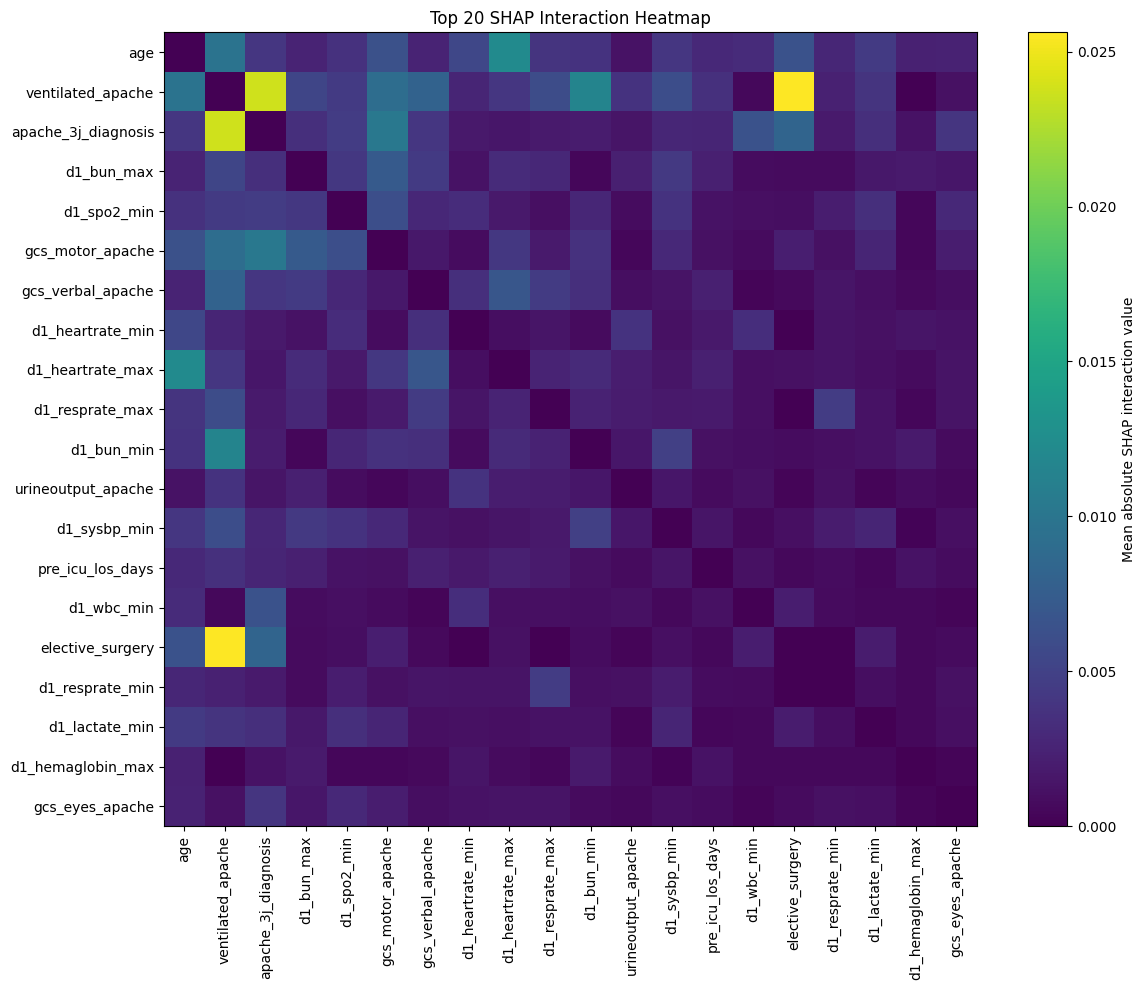

In [46]:
plt.figure(figsize=(12, 10))

im = plt.imshow(
    interaction_matrix_df,
    cmap="viridis",
    aspect="auto"
)

plt.colorbar(im, label="Mean absolute SHAP interaction value")

plt.xticks(
    ticks=np.arange(len(interaction_matrix_df.columns)),
    labels=interaction_matrix_df.columns,
    rotation=90
)

plt.yticks(
    ticks=np.arange(len(interaction_matrix_df.index)),
    labels=interaction_matrix_df.index
)

plt.title("Top 20 SHAP Interaction Heatmap")
plt.tight_layout()

plt.savefig(
    explainability_dir / "top20_shap_interaction_heatmap.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

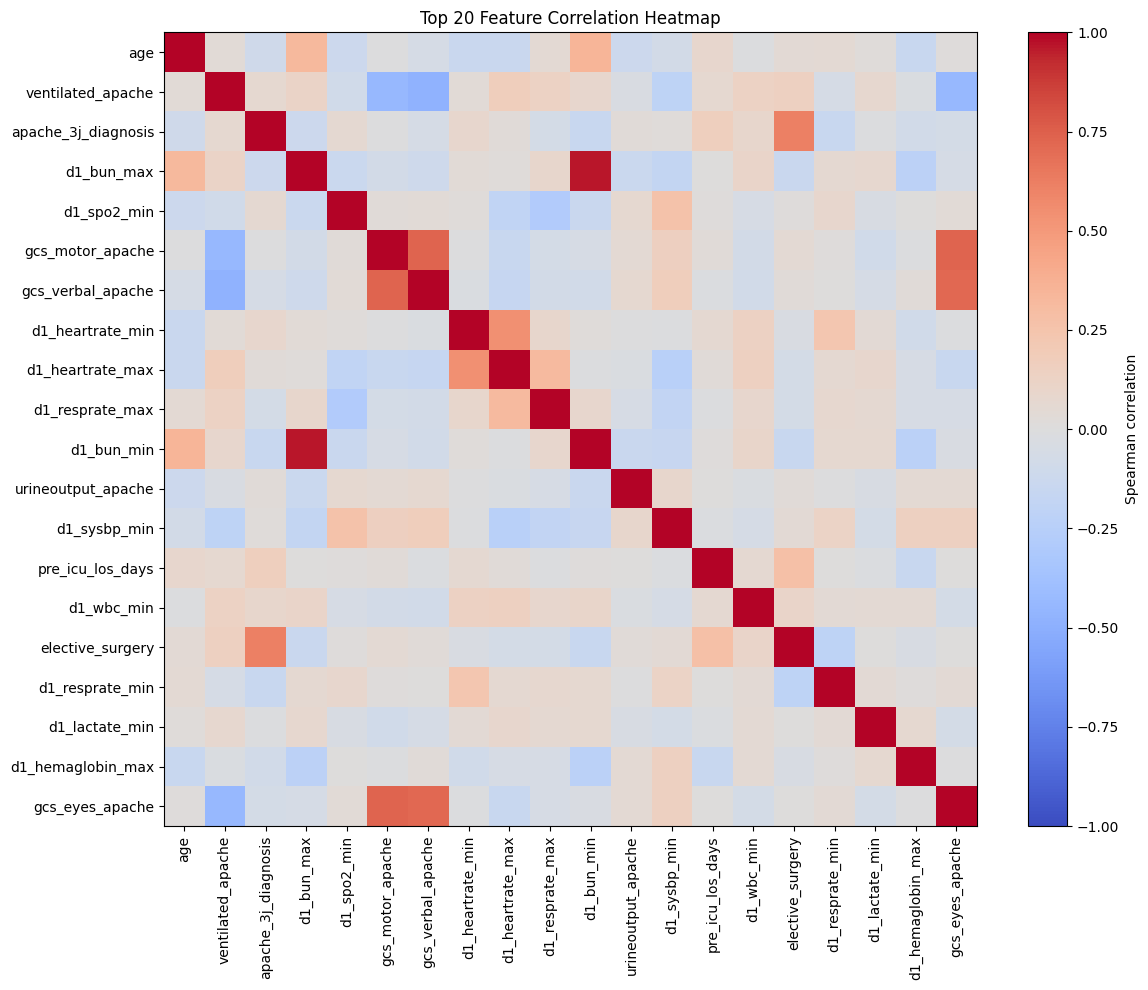

In [47]:
top20_corr = X_shap[top20_features].corr(method="spearman")

plt.figure(figsize=(12, 10))

im = plt.imshow(
    top20_corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    aspect="auto"
)

plt.colorbar(im, label="Spearman correlation")

plt.xticks(
    ticks=np.arange(len(top20_corr.columns)),
    labels=top20_corr.columns,
    rotation=90
)

plt.yticks(
    ticks=np.arange(len(top20_corr.index)),
    labels=top20_corr.index
)

plt.title("Top 20 Feature Correlation Heatmap")
plt.tight_layout()

plt.savefig(
    explainability_dir / "top20_feature_correlation_heatmap.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## Final Preprocessing Check — ID and Location Variables Removed

Earlier exploratory analysis showed that `icu_id` could capture unit/location patterns rather than direct patient physiology. In the final model, ID and location-like columns are removed before fitting the preprocessor and model.

This section keeps the caution analysis as a methodological record: the project did not simply ignore the `icu_id` concern; it converted that finding into a preprocessing decision.

In [48]:
# Confirm that ID/location and leakage columns are absent from the final SHAP matrix.
removed_columns = [
    'encounter_id',
    'patient_id',
    'hospital_id',
    'icu_id',
    'apache_4a_hospital_death_prob',
    'apache_4a_icu_death_prob',
]

removed_column_check = pd.DataFrame({
    'column': removed_columns,
    'present_in_final_X_shap': [column in X_shap.columns for column in removed_columns]
})

removed_column_check

,column,present_in_final_X_shap
0,encounter_id,False
1,patient_id,False
2,hospital_id,False
3,icu_id,False
4,apache_4a_hospital_death_prob,False
5,apache_4a_icu_death_prob,False


In [49]:
# Descriptive ICU-level mortality analysis kept as historical justification for removing icu_id.
raw_df = pd.read_csv('../data/raw/training_v2.csv')

icu_mortality = (
    raw_df
    .groupby('icu_id')['hospital_death']
    .agg(n_patients='count', mortality_rate='mean')
    .reset_index()
)

icu_mortality['mortality_rate_pct'] = (icu_mortality['mortality_rate'] * 100).round(2)

icu_mortality_filtered = (
    icu_mortality
    .query('n_patients >= 100')
    .sort_values('mortality_rate', ascending=False)
    .reset_index(drop=True)
)

print(f'Total ICU IDs: {icu_mortality.shape[0]}')
print(f'ICU IDs with >=100 patients: {icu_mortality_filtered.shape[0]}')

icu_mortality_filtered.head(20)

Total ICU IDs: 241
ICU IDs with >=100 patients: 194


,icu_id,n_patients,mortality_rate,mortality_rate_pct
0,698,110,0.290909,29.09
1,290,302,0.201987,20.20
2,628,657,0.188737,18.87
3,632,492,0.178862,17.89
4,495,603,0.175788,17.58
5,256,309,0.174757,17.48
6,601,559,0.171735,17.17
7,285,413,0.162228,16.22
8,487,298,0.161074,16.11
9,513,820,0.159756,15.98


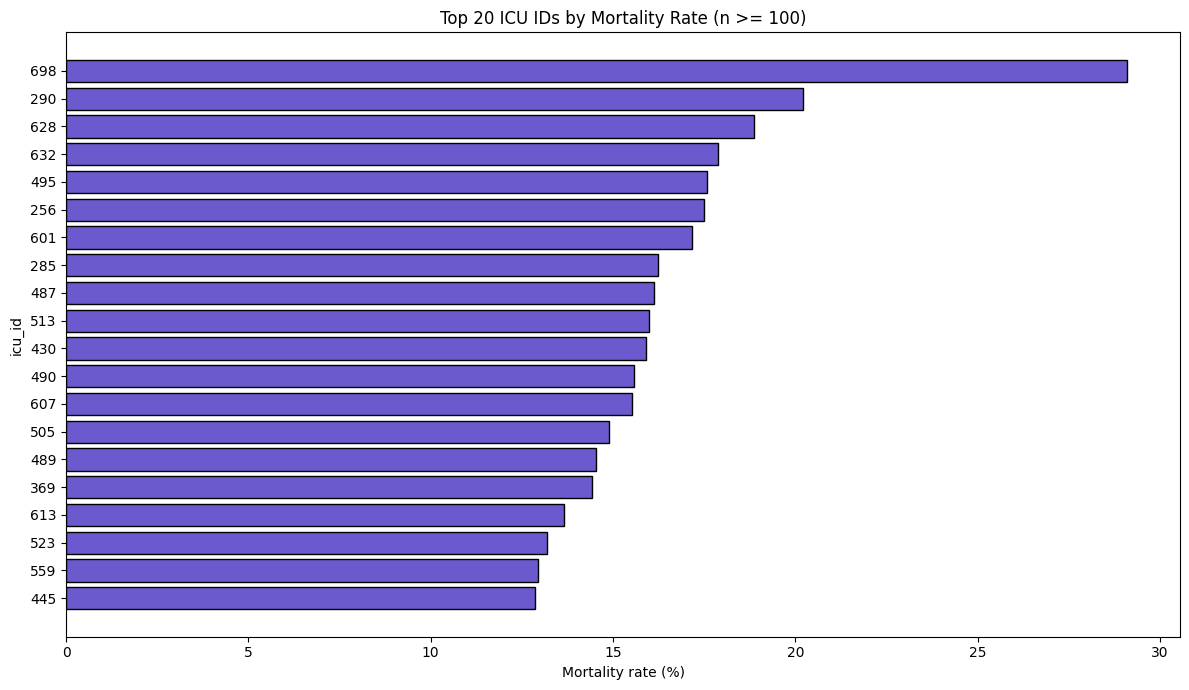

In [50]:
top_icu_mortality = icu_mortality_filtered.head(20).copy()

plt.figure(figsize=(12, 7))
plt.barh(
    top_icu_mortality['icu_id'].astype(str),
    top_icu_mortality['mortality_rate_pct'],
    color='slateblue',
    edgecolor='black'
)
plt.xlabel('Mortality rate (%)')
plt.ylabel('icu_id')
plt.title('Top 20 ICU IDs by Mortality Rate (n >= 100)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

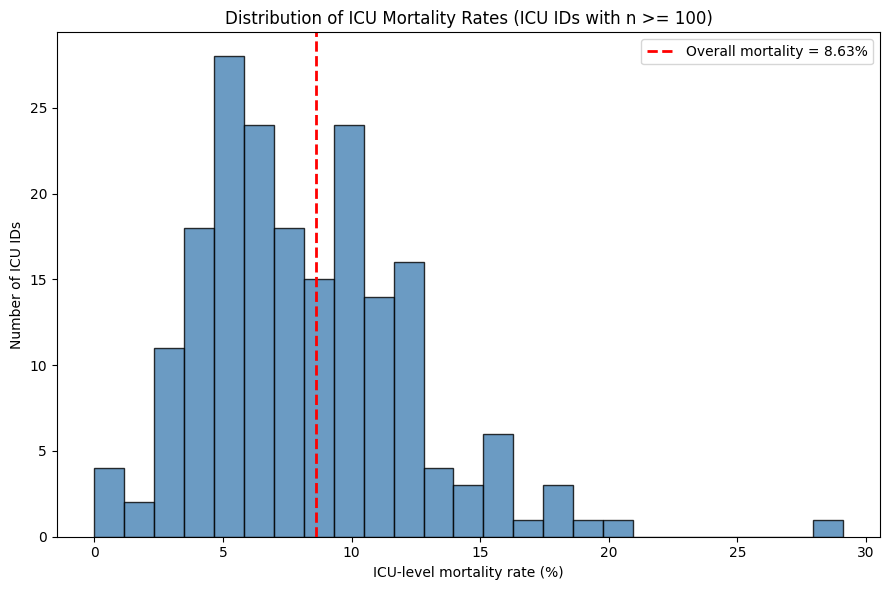

In [51]:
plt.figure(figsize=(9, 6))
plt.hist(
    icu_mortality_filtered['mortality_rate_pct'],
    bins=25,
    color='steelblue',
    edgecolor='black',
    alpha=0.8
)
plt.axvline(
    raw_df['hospital_death'].mean() * 100,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f"Overall mortality = {raw_df['hospital_death'].mean() * 100:.2f}%"
)
plt.xlabel('ICU-level mortality rate (%)')
plt.ylabel('Number of ICU IDs')
plt.title('Distribution of ICU Mortality Rates (ICU IDs with n >= 100)')
plt.legend()
plt.tight_layout()
plt.show()

In [52]:
from pathlib import Path

caution_dir = Path('../reports/02_explainability/caution_analysis')
caution_dir.mkdir(parents=True, exist_ok=True)

removed_column_check.to_csv(
    caution_dir / 'removed_id_location_columns.csv',
    index=False
)

icu_mortality_filtered.to_csv(
    caution_dir / 'icu_id_mortality_by_unit.csv',
    index=False
)

print('Saved:')
print(caution_dir / 'removed_id_location_columns.csv')
print(caution_dir / 'icu_id_mortality_by_unit.csv')

Saved:
../reports/02_explainability/caution_analysis/removed_id_location_columns.csv
../reports/02_explainability/caution_analysis/icu_id_mortality_by_unit.csv


### Interpretation — How the `icu_id` finding changed the final pipeline

The earlier `icu_id` analysis showed that ICU-level mortality rates vary across units and that unit/location identifiers can become model signals. Since `icu_id` is not a direct patient-level clinical measurement, the final pipeline removes it together with other ID/location columns.

This makes the final evidence packets and LLM explanations cleaner: explanations are no longer driven by unit identifiers and instead focus on patient-level clinical measurements, coded diagnosis/severity categories, and treatment indicators. The remaining caution flags now focus mainly on zero-valued vital signs and unusual values rather than `icu_id`.